In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="white")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
holdings = pd.read_csv("C:\\Users\\tekam\\Downloads\\Data Science\\Data_Analyst_Portfolio_Project\\data\\raw\\09_portfolio_holdings.csv")

print("Shape :", holdings.shape)

display(holdings.head())

Shape : (322, 8)


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [3]:
# Portfolio Date

holdings["portfolio_date"] = pd.to_datetime(
    holdings["portfolio_date"]
)

# Remove Missing Sectors

holdings = holdings.dropna(subset=["sector"])

# Ensure Weight is Numeric

holdings["weight_pct"] = pd.to_numeric(
    holdings["weight_pct"],
    errors="coerce"
)

holdings = holdings.dropna(subset=["weight_pct"])

display(holdings.head())

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [4]:
sector_df = (

    holdings

    .groupby("sector", as_index=False)["weight_pct"]

    .sum()

    .sort_values(

        "weight_pct",

        ascending=False

    )

)

display(sector_df)

,sector,weight_pct
1,Banking,652.26
7,IT,455.47
11,Pharma,407.45
0,Automobile,323.65
13,Utilities,265.54
6,FMCG,229.11
8,Infrastructure,192.16
4,Diversified,169.23
12,Telecom,145.62
3,Consumer Goods,127.61


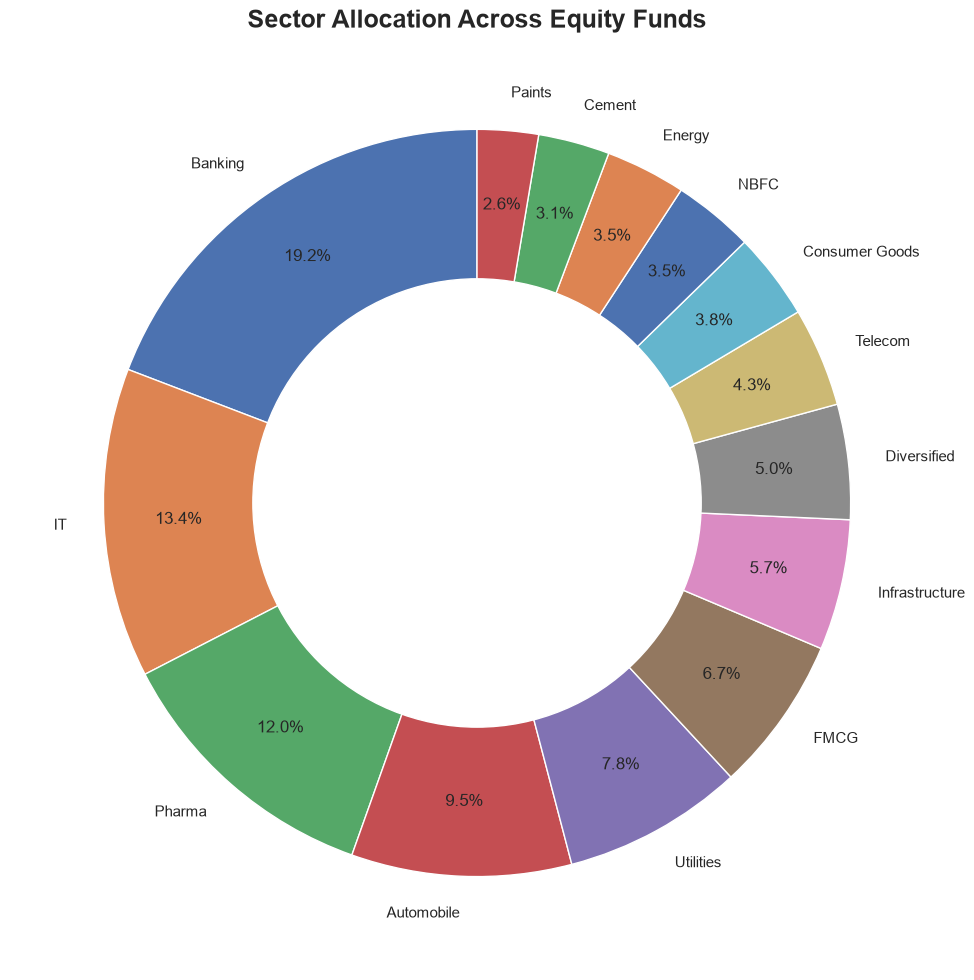

In [5]:
plt.figure(figsize=(10,10))

wedges, texts, autotexts = plt.pie(

    sector_df["weight_pct"],

    labels=sector_df["sector"],

    autopct="%1.1f%%",

    startangle=90,

    pctdistance=0.80

)

# Donut Hole

centre_circle = plt.Circle(

    (0,0),

    0.60,

    fc="white"

)

plt.gca().add_artist(

    centre_circle

)

plt.title(

    "Sector Allocation Across Equity Funds",

    fontsize=18,

    weight="bold"

)

plt.tight_layout()

plt.show()

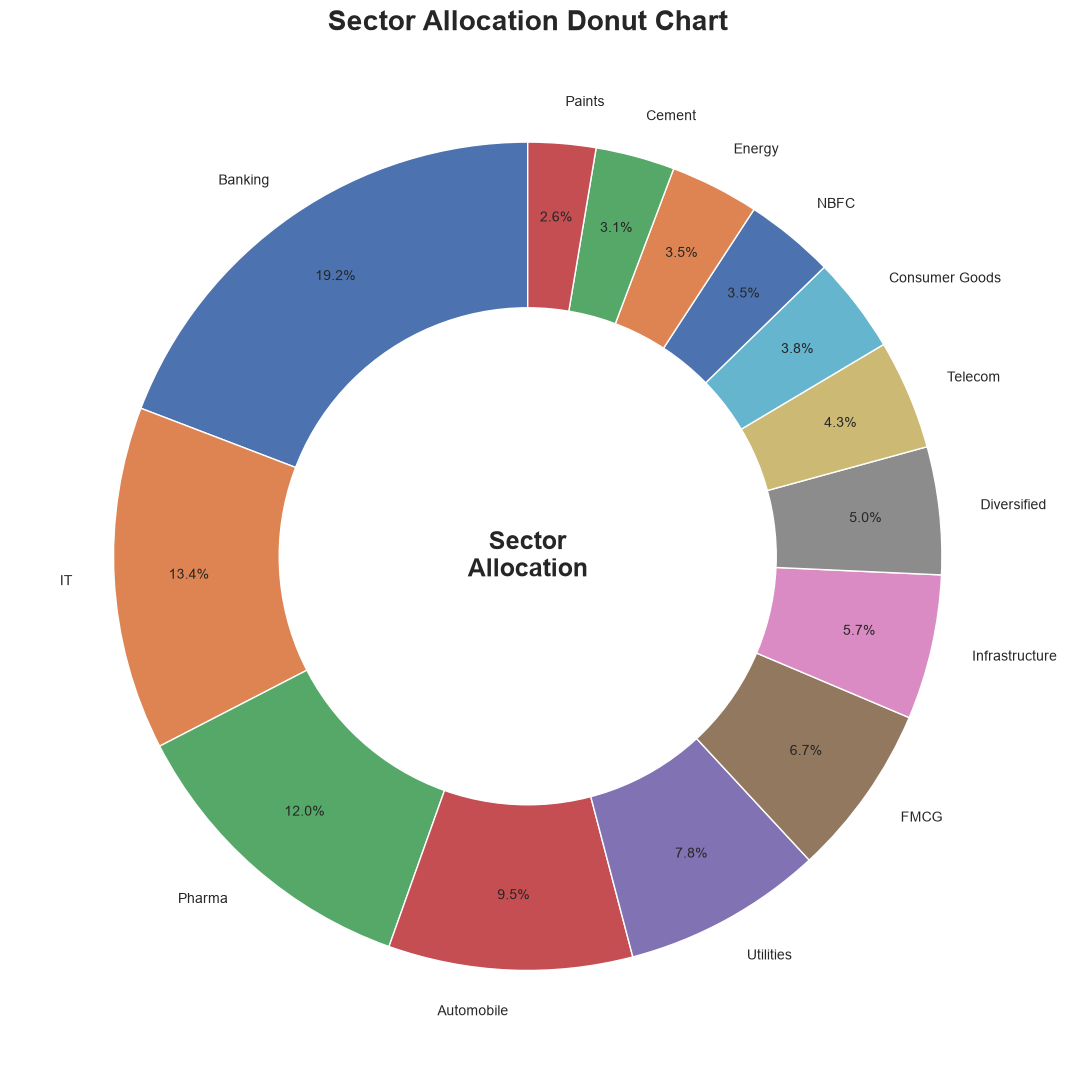

In [6]:
plt.figure(figsize=(11,11))

wedges, texts, autotexts = plt.pie(

    sector_df["weight_pct"],

    labels=sector_df["sector"],

    autopct="%1.1f%%",

    startangle=90,

    pctdistance=0.82,

    textprops={"fontsize":10}

)

centre_circle = plt.Circle(

    (0,0),

    0.60,

    fc="white"

)

plt.gca().add_artist(

    centre_circle

)

plt.text(

    0,

    0,

    "Sector\nAllocation",

    ha="center",

    va="center",

    fontsize=18,

    weight="bold"

)

plt.title(

    "Sector Allocation Donut Chart",

    fontsize=20,

    weight="bold"

)

plt.tight_layout()

plt.show()

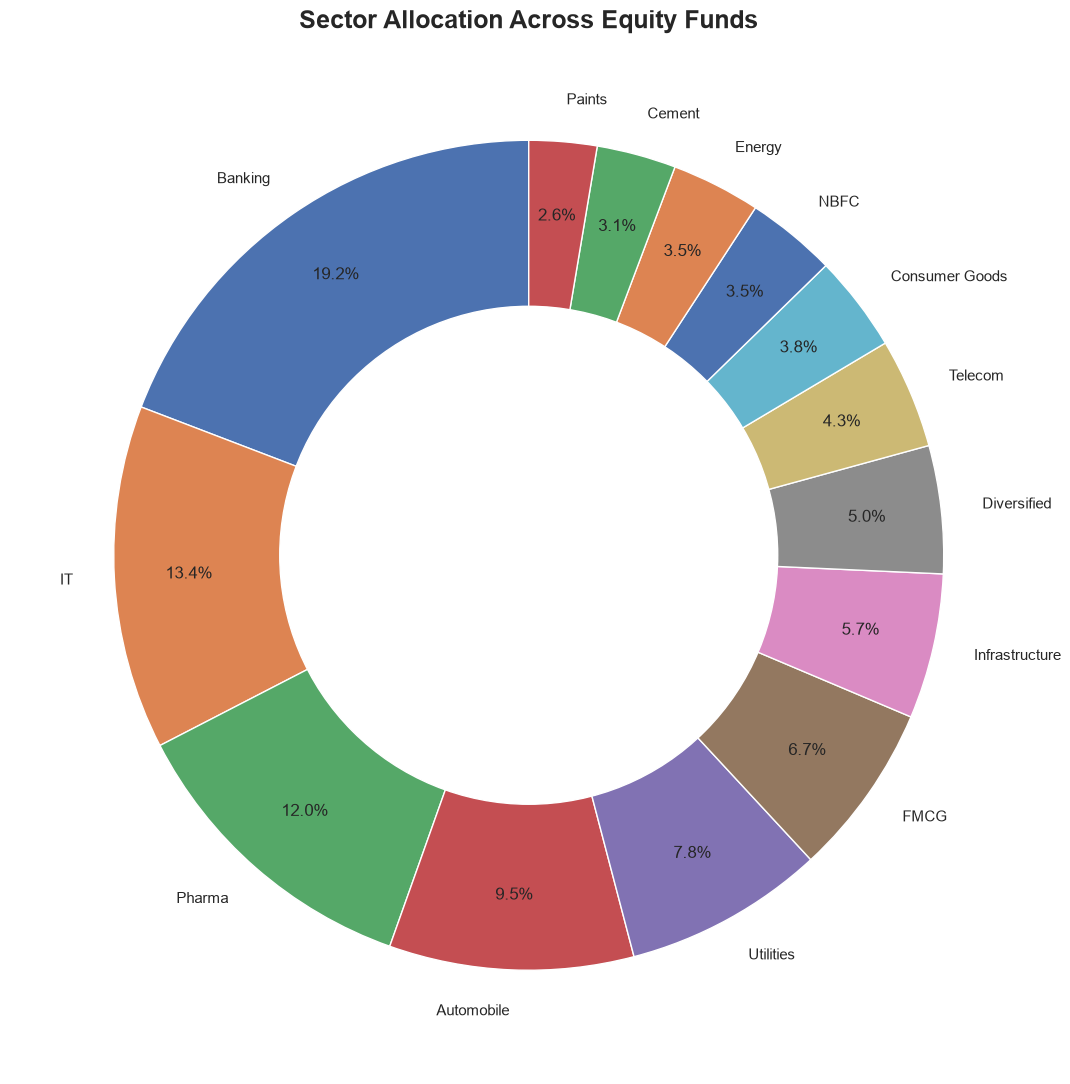

✅ Donut Chart Saved Successfully


In [7]:
os.makedirs("dashboard", exist_ok=True)

plt.figure(figsize=(11,11))

wedges, texts, autotexts = plt.pie(

    sector_df["weight_pct"],

    labels=sector_df["sector"],

    autopct="%1.1f%%",

    startangle=90,

    pctdistance=0.82

)

centre_circle = plt.Circle(

    (0,0),

    0.60,

    fc="white"

)

plt.gca().add_artist(

    centre_circle

)

plt.title(

    "Sector Allocation Across Equity Funds",

    fontsize=18,

    weight="bold"

)

plt.tight_layout()

plt.savefig(

    "dashboard/sector_allocation_donut.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

print("✅ Donut Chart Saved Successfully")